In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [ ]:
# Carregar dataset
df = pd.read_csv('Finance_data.csv')
print("Total de registros:", len(df))
print(df.head())

Total de registros: 40
   gender  age Investment_Avenues  Mutual_Funds  Equity_Market  Debentures  \
0  Female   34                Yes             1              2           5   
1  Female   23                Yes             4              3           2   
2    Male   30                Yes             3              6           4   
3    Male   22                Yes             2              1           3   
4  Female   24                 No             2              1           3   

   Government_Bonds  Fixed_Deposits  PPF  Gold  ...           Duration  \
0                 3               7    6     4  ...          1-3 years   
1                 1               5    6     7  ...  More than 5 years   
2                 2               5    1     7  ...          3-5 years   
3                 7               6    4     5  ...   Less than 1 year   
4                 6               4    5     7  ...   Less than 1 year   

  Invest_Monitor   Expect       Avenue What are your savings ob

In [ ]:
# Usar apenas as colunas numericas para analise
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df_numerico = df[numeric_cols].copy()

print(df_numerico.head())

   age  Mutual_Funds  Equity_Market  Debentures  Government_Bonds  \
0   34             1              2           5                 3   
1   23             4              3           2                 1   
2   30             3              6           4                 2   
3   22             2              1           3                 7   
4   24             2              1           3                 6   

   Fixed_Deposits  PPF  Gold  
0               7    6     4  
1               5    6     7  
2               5    1     7  
3               6    4     5  
4               4    5     7  


In [ ]:
# Cálculo do Z-score
z_scores = stats.zscore(df[numeric_cols])

# Converter para DataFrame
outliers_zscore = pd.DataFrame(
    np.abs(z_scores) > 3,
    columns=numeric_cols
)

# Contagem de outliers por coluna
print("Outliers via Z-Score por coluna:")
for col in numeric_cols:
    print(f"{col}: {outliers_zscore[col].sum()}")


Outliers via Z-Score por coluna:
age: 0
Mutual_Funds: 1
Equity_Market: 0
Debentures: 0
Government_Bonds: 0
Fixed_Deposits: 0
PPF: 0
Gold: 1


In [ ]:
# Usando o IQR
Q1 = df_numerico.quantile(0.25)
Q3 = df_numerico.quantile(0.75)
IQR = Q3 - Q1

outliers_iqr = (df_numerico < (Q1 - 1.5 * IQR)) | \
               (df_numerico > (Q3 + 1.5 * IQR))

print("\nOutliers via IQR por coluna:")
for col in numeric_cols:
    print(f"{col}: {outliers_iqr[col].sum()}")


Outliers via IQR por coluna:
age: 0
Mutual_Funds: 3
Equity_Market: 4
Debentures: 1
Government_Bonds: 7
Fixed_Deposits: 0
PPF: 5
Gold: 4


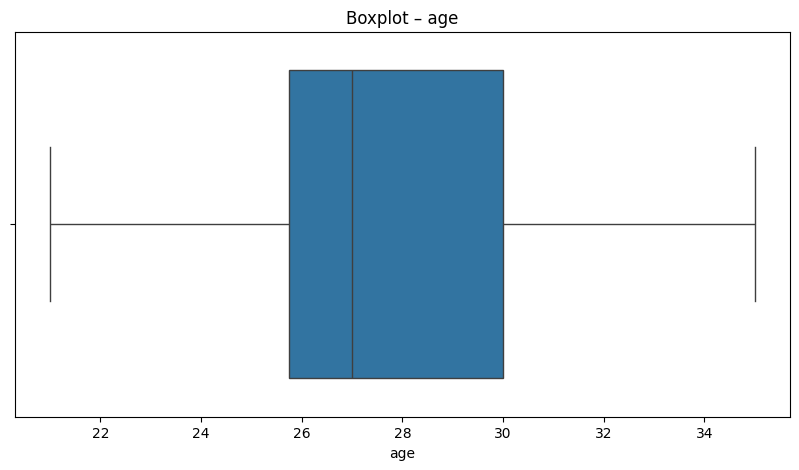

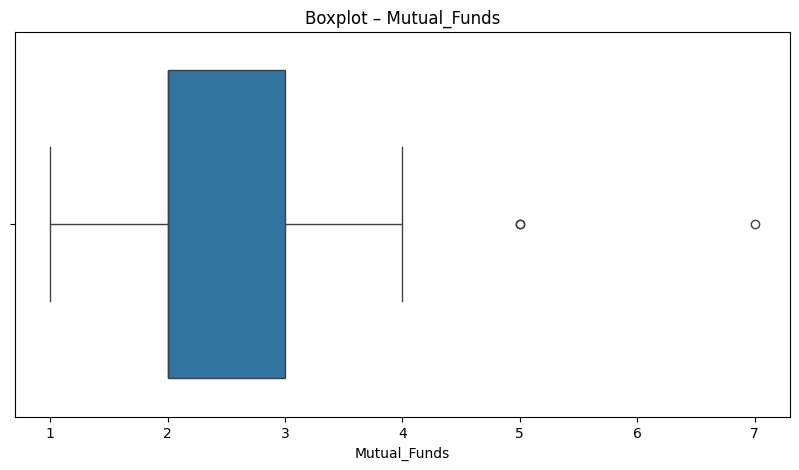

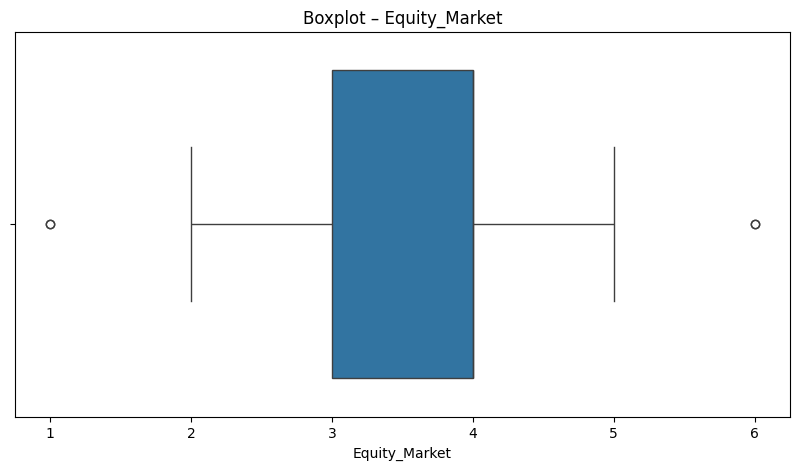

In [ ]:
# Grafico boxplot para visualização do outliers
for col in numeric_cols[:3]:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=df_numerico[col])
    plt.title(f'Boxplot – {col}')
    plt.show()

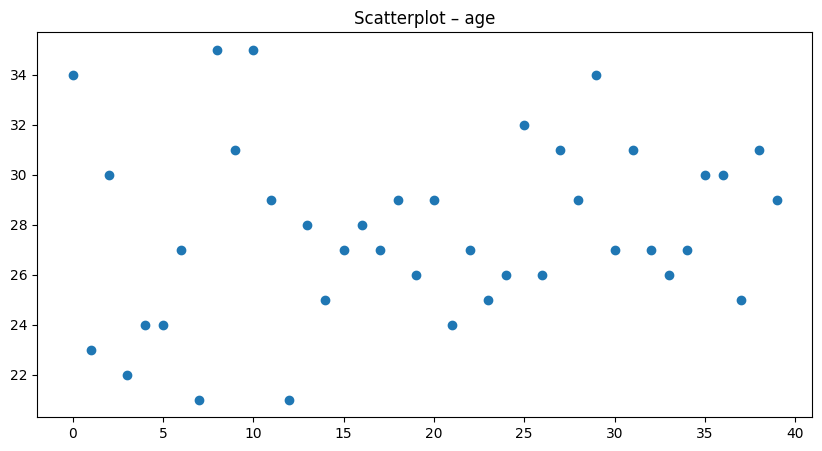

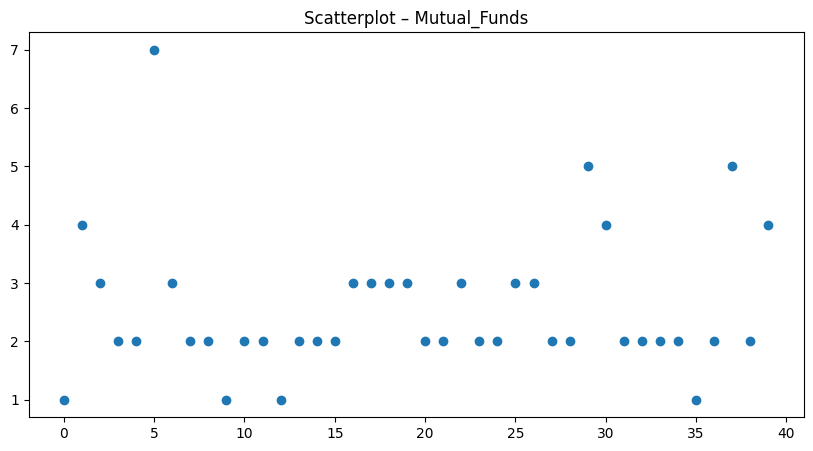

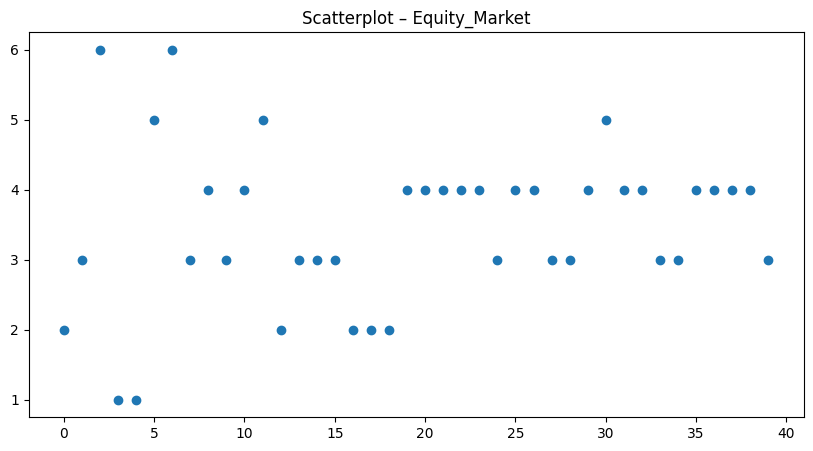

In [ ]:
# Scatterplot
for col in numeric_cols[:3]:
    plt.figure(figsize=(10, 5))
    plt.scatter(range(len(df_numerico[col])), df_numerico[col])
    plt.title(f"Scatterplot – {col}")
    plt.show()

In [ ]:
# Estratégia 1 - Remoção desses outliers
df_remover = df_numerico[
    ~(outliers_iqr.any(axis=1))
].copy()

print("Antes:", len(df_numerico))
print("Depois:", len(df_remover))

Antes: 40
Depois: 26


In [ ]:
# Estratégia 2 - Substitui valores fora dos limites pelo valor min e max
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_capped = df_numerico.copy()

for col in numeric_cols:
    df_capped[col] = np.where(
        df_capped[col] < lower_bound[col], lower_bound[col], df_capped[col]
    )
    df_capped[col] = np.where(
        df_capped[col] > upper_bound[col], upper_bound[col], df_capped[col]
    )


In [ ]:
# Estrategia 3 - Tranformação LOG
df_log = df_numerico.copy()
for col in numeric_cols:
    df_log[col] = np.log1p(df_log[col] - df_log[col].min() + 1)

In [ ]:
# Comparação entre as analises e alterações feitas.
comparacao = pd.DataFrame({
    "Original Média": df_numerico.mean(),
    "Original Desvio": df_numerico.std(),
    "Removido Média": df_remover.mean(),
    "Capping Média": df_capped.mean(),
    "Log Média": df_log.mean(),
})

print(comparacao)


                  Original Média  Original Desvio  Removido Média  \
age                       27.800         3.560467       28.346154   
Mutual_Funds               2.550         1.197219        2.192308   
Equity_Market              3.475         1.131994        3.423077   
Debentures                 5.750         1.675617        6.653846   
Government_Bonds           4.650         1.369072        4.923077   
Fixed_Deposits             3.575         1.795828        3.153846   
PPF                        2.025         1.609069        1.461538   
Gold                       5.975         1.143263        6.192308   

                  Capping Média  Log Média  
age                   27.800000   2.074536  
Mutual_Funds           2.462500   1.220284  
Equity_Market          3.475000   1.463325  
Debentures             5.775000   1.867416  
Government_Bonds       4.712500   1.694297  
Fixed_Deposits         3.575000   1.433391  
PPF                    1.840625   1.000655  
Gold              